# Laser step-down, 2026-09-14 -> 09-15

**Time period covered: front-end GPS 1473468171 -> ~1473530658 (2026-09-14 21:52:36 UTC
-> 2026-09-15 ~15:11 UTC, ~17.3 h of controlled steps).** The pulled h5 window is a
round bracket around that, GPS 1473468000 -> 1473531000 (17.50 h). `LASER_OFFSET` was
stepped 1300 -> 1000 across 12 commanded values (50-count steps 1300->1050, then
10-count 1050->1000, with 1000 repeated once to test whether the non-settling behaviour
was real). Then stopped by hand and the laser returned to 1300.

This is the actual per-step frequency extraction (f_ss, tau) behind the headline
results already logged in `apparatus_log.md` ("2026-09-14" and "2026-09-15 -- laser
step-down RUN RESULTS" entries) and planned in `laser_stepdown_next_run_plan.md`. Data:
Dropbox `Microspheres/TFINER/stepdown_20260914/` (LES_YAW, LES_PIT, PD h5 + the
`laser_stepdown_log_gps1473468167.csv` step/settled-check log).

**Baseline: 1300 counts = 0.75 Hz rotor** (LES line 1.5 Hz = 2x the 2-fold sail;
DIVISOR=2, confirmed 2026-09-14 by live timing -- see `apparatus_log.md`).

**Carried in from the log, not re-derived here:**
- **The PD (laser power monitor) is suspect** -- probably misaligned to the pick-off
  (beam-walk signature, not a clean power proxy). Use commanded **counts**, not PD, as
  the power axis. This notebook's PD section (S4) is a check of that claim, not a
  correction of it.
- **On-drive relaxation is slow (July: tau ~ 160 min, ~2.4x the free-decay tau)**, so a
  70-min hold is only partially settled -- f_ss should come from fitting the transient,
  not from reading the last held value.
- **1000 counts does not plateau** -- confirmed twice in the run (steps i=10 and i=11,
  same offset). Any exponential fit to those two is a description of a still-declining
  trace, not a real f_ss; treated separately below, not averaged into the threshold plot
  as if settled.

In [1]:
import numpy as np, os, h5py
import matplotlib.pyplot as plt
from scipy.signal import decimate
from scipy.optimize import curve_fit

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/stepdown_20260914')
GPS_A, GPS_B = 1473468000, 1473531000   # pulled h5 window (front-end GPS)
DIVISOR = 2                              # rotation = LES line / 2, confirmed 2026-09-14

def load(path):
    # Segment-aware .h5 reader -- same pattern as analysis/spindown_20260913.ipynb.
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        t = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

les, t_les, fs = load(os.path.join(DATA, f'Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'))
pd_, t_pd, _   = load(os.path.join(DATA, f'Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5'))
assert np.allclose(t_les, t_pd), 'LES and PD time axes differ'
print(f'{len(les)/fs:.0f} s at {fs:.0f} Hz  ({(t_les[-1]-t_les[0])/3600:.2f} h)')
print(f'GPS {t_les[0]:.0f} .. {t_les[-1]:.0f}')

63000 s at 1024 Hz  (17.50 h)
GPS 1473468000 .. 1473531000


## 1. The commanded schedule -- parsed from the run log

`laser_stepdown_log_gps1473468167.csv` mixes two row shapes (a `step` line per
commanded change, `check` lines for every settled-check poll in between). Parse the
`step` lines only here; they carry the offset, the front-end GPS the step began at, and
a UTC string already corrected for the cymac clock offset (see
`project_cymac_gps_offset.md` -- do not re-derive UTC from the GPS column by hand, the
front-end clock drifts against true GPS and the log's own UTC field already accounts
for it).

In [2]:
CSV = os.path.join(DATA, 'laser_stepdown_log_gps1473468167.csv')

steps = []
with open(CSV) as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) > 2 and parts[1] == 'step' and parts[2].startswith('i='):
            d = dict(tok.split('=', 1) for tok in parts[2:] if '=' in tok)
            steps.append({'i': int(d['i']), 'offset': float(d['offset']),
                          'gps': int(d['gps']), 'utc': d['UTC']})

bounds = [s['gps'] for s in steps] + [t_les[-1]]   # step k active [bounds[k], bounds[k+1])

print(f'{len(steps)} commanded steps')
for s in steps:
    print('  i=%2d  offset=%5.0f  %s' % (s['i'], s['offset'], s['utc']))

12 commanded steps
  i= 0  offset= 1300  2026-09-14T21:52:36Z
  i= 1  offset= 1250  2026-09-14T23:02:38Z
  i= 2  offset= 1200  2026-09-15T00:12:39Z
  i= 3  offset= 1150  2026-09-15T01:22:40Z
  i= 4  offset= 1100  2026-09-15T02:32:41Z
  i= 5  offset= 1050  2026-09-15T03:42:42Z
  i= 6  offset= 1040  2026-09-15T04:52:43Z
  i= 7  offset= 1030  2026-09-15T06:02:44Z
  i= 8  offset= 1020  2026-09-15T08:02:46Z
  i= 9  offset= 1010  2026-09-15T09:37:48Z
  i=10  offset= 1000  2026-09-15T10:47:49Z
  i=11  offset= 1000  2026-09-15T12:47:51Z


## 2. Dense rotor-frequency track over the full run

Same band-following tracker as `analysis/spindown_20260913.ipynb`: decimate to 16 Hz,
150 s windows every 60 s, FFT peak with parabolic sub-bin interpolation, search band
re-centred on the previous estimate (0.80x-1.15x) so it can follow both the slow
within-step drift and the between-step jumps without losing lock.

In [3]:
y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16

def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

WIN, STEP = 150.0, 60.0
nw, sw = int(WIN*fs16), int(STEP*fs16)

rows = []
track = 1.50   # LES line ~1.5 Hz at the 1300 baseline (0.75 Hz rotor x2)
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.80, 0.02), track*1.15)
    if np.isnan(fpk) or fpk <= 0: continue
    rows.append((tc, fpk, fpk/DIVISOR, snr))
    track = fpk

T = np.array([r[0] for r in rows]); LINE = np.array([r[1] for r in rows])
FR = np.array([r[2] for r in rows]); SNR = np.array([r[3] for r in rows])
print(f'{len(T)} estimates, t={T[0]:.0f}..{T[-1]:.0f} ({(T[-1]-T[0])/3600:.2f} h)')
print(f'rotor freq range {FR.min():.4f} .. {FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

1048 estimates, t=1473468075..1473530895 (17.45 h)
rotor freq range 0.6917 .. 0.7520 Hz, median SNR 446


## 3. Full-run overview: frequency, PD, and the step boundaries

Reproduces the quick-look plot (`run_freq_stepdown.png`, made live during the run) from
the archived data, with the commanded counts labelled at each step and the PD trend
alongside it for a direct visual read on whether PD tracks the frequency response.

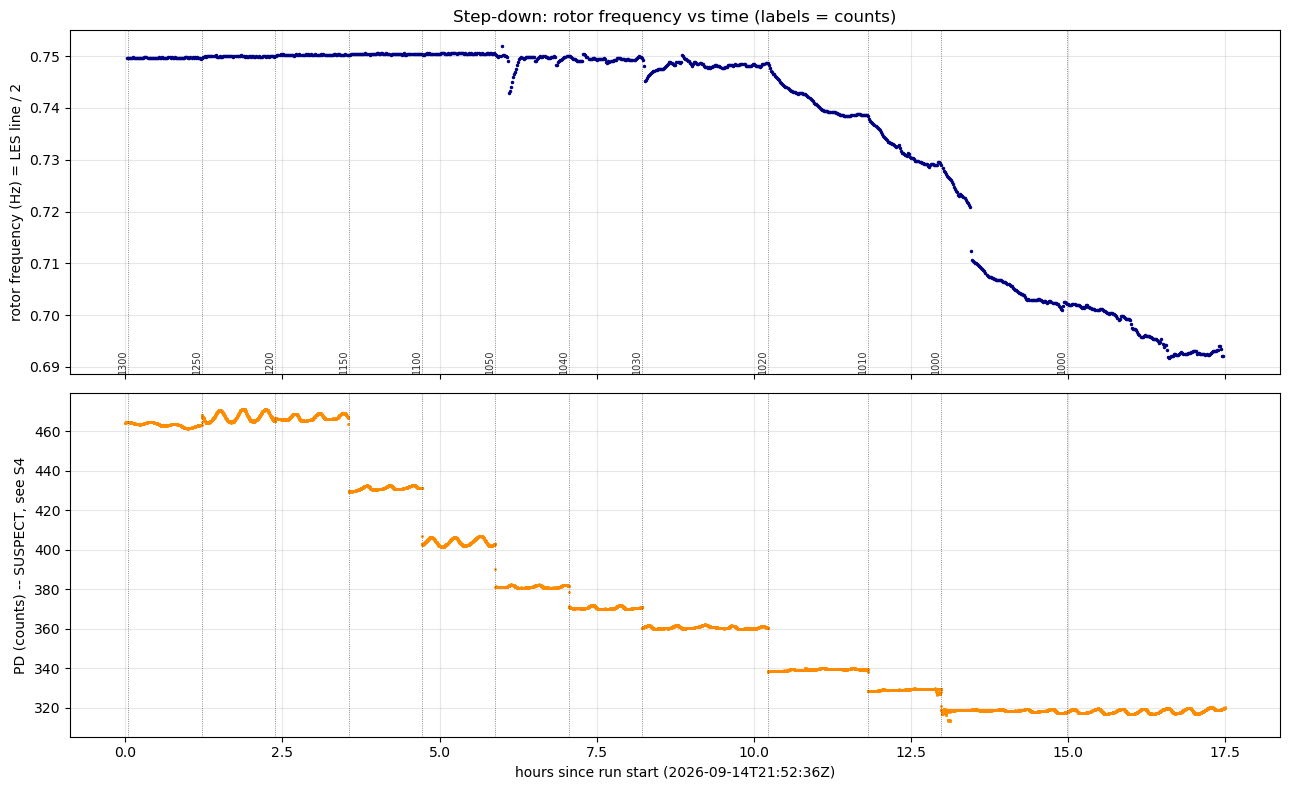

In [4]:
# block-average PD at 5 s, matching analysis/spindown_20260913.ipynb's PD-check pattern
blk = int(5*fs)
n = len(pd_)//blk
tb = np.array([t_pd[i*blk] for i in range(n)])
pdb = np.array([pd_[i*blk:(i+1)*blk].mean() for i in range(n)])

t0 = t_les[0]
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax[0].plot((T-t0)/3600, FR, '.', ms=3, color='navy')
ax[0].set_ylabel('rotor frequency (Hz) = LES line / 2')
ax[0].set_title('Step-down: rotor frequency vs time (labels = counts)')

ax[1].plot((tb-t0)/3600, pdb, '.', ms=2, color='darkorange')
ax[1].set_ylabel('PD (counts) -- SUSPECT, see S4')
ax[1].set_xlabel('hours since run start (' + steps[0]['utc'] + ')')

for s in steps:
    th = (s['gps']-t0)/3600
    for a in ax:
        a.axvline(th, color='k', ls=':', lw=0.6, alpha=0.6)
    ax[0].text(th, ax[0].get_ylim()[0], '%.0f' % s['offset'], rotation=90,
               fontsize=7, va='bottom', ha='right', alpha=0.8)

for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. PD sanity check -- is it usable as the power axis?

Per-step PD mean/std (skipping each step's first 5 min so this isn't contaminated by
the transient). This is an independent check of the log's "PD is suspect" call, not a
re-measurement of true optical power -- there is no Ophir reading in this dataset to
calibrate against.

In [5]:
print('%3s %7s %9s %8s' % ('i', 'offset', 'PD mean', 'PD std'))
pd_rows = []
for k, s in enumerate(steps):
    t0s, t1s = bounds[k], bounds[k+1]
    m = (t_pd >= t0s+300) & (t_pd < t1s)
    seg = pd_[m]
    if len(seg) == 0: continue
    pd_rows.append((s['offset'], seg.mean(), seg.std()))
    print('%3d %7.0f %9.2f %8.2f' % (k, s['offset'], seg.mean(), seg.std()))

pd_offsets = np.array([r[0] for r in pd_rows])
pd_means   = np.array([r[1] for r in pd_rows])
print()
print('PD is NOT monotonic in counts: rises %.0f->%.0f (%.1f->%.1f) before declining.'
      % (pd_offsets[0], pd_offsets[1], pd_means[0], pd_means[1]))
print("Confirms the log's 'beam-walk, not clean power' read -- treat commanded counts as the power axis.")

  i  offset   PD mean   PD std


  0    1300    463.23     5.24
  1    1250    467.58     3.26
  2    1200    467.00     5.98


  3    1150    431.29     6.43
  4    1100    404.01     4.26
  5    1050    381.26     6.81
  6    1040    370.55     6.99


  7    1030    360.62     7.07
  8    1020    339.34     7.07


  9    1010    329.09     7.06
 10    1000    318.51     6.96


 11    1000    318.25     7.14

PD is NOT monotonic in counts: rises 1300->1250 (463.2->467.6) before declining.
Confirms the log's 'beam-walk, not clean power' read -- treat commanded counts as the power axis.


## 5. Per-step transient fit: f_ss and tau

`f(t) = f_ss + (f0 - f_ss)*exp(-t/tau)` fit to each step's dense frequency track
(first 5 min excluded as the switching transient). This recovers the asymptotic f_ss
even from a partially-settled hold, which matters here because on-drive tau can be
~160 min against ~70-min dwells (see the note at the top).

**Steps i=10 and i=11 (both offset=1000) are fit and reported the same way for
completeness, but the log already established neither one plateaus** -- read their
f_ss as "still declining, not a steady state," not as a real threshold point.

In [6]:
def model(t, fss, f0, tau):
    return fss + (f0-fss)*np.exp(-t/tau)

results = []
print('%3s %7s %4s %7s %8s %9s %9s' % ('i', 'offset', 'n', 'dur(h)', 'f_ss', 'tau(min)', 'rms(mHz)'))
for k, s in enumerate(steps):
    t0s, t1s = bounds[k], bounds[k+1]
    m = (T >= t0s) & (T < t1s)
    tt, ff = T[m]-t0s, FR[m]
    fit_m = tt > 300
    tt_f, ff_f = tt[fit_m], ff[fit_m]
    dur_h = (t1s-t0s)/3600
    if len(tt_f) < 5:
        print('%3d %7.0f  too few points (%d)' % (k, s['offset'], len(tt_f)))
        continue
    try:
        p0 = [ff_f[-1], ff_f[0], 3000]
        popt, _ = curve_fit(model, tt_f, ff_f, p0=p0, maxfev=20000,
                             bounds=([0.4, 0.4, 60], [1.0, 1.0, 3600*8]))
        fss, f0, tau = popt
        rms = np.sqrt(np.mean((ff_f - model(tt_f, *popt))**2))
        flag = '  <-- does not plateau (see S5 note)' if s['offset'] == 1000 else ''
        print('%3d %7.0f %4d %7.2f %8.4f %9.1f %9.3f%s' %
              (k, s['offset'], len(tt_f), dur_h, fss, tau/60, rms*1e3, flag))
        results.append({'i': k, 'offset': s['offset'], 'f_ss': fss, 'tau_min': tau/60,
                         'rms_mHz': rms*1e3, 'n': len(tt_f), 'plateaued': s['offset'] != 1000})
    except Exception as e:
        print('%3d %7.0f  fit failed: %s' % (k, s['offset'], e))

  i  offset    n  dur(h)     f_ss  tau(min)  rms(mHz)
  0    1300   65    1.17   0.7497      22.6     0.060
  1    1250   65    1.17   0.7495     480.0     0.066
  2    1200   65    1.17   0.7503      21.6     0.059
  3    1150   66    1.17   0.7504       5.8     0.068
  4    1100   65    1.17   0.7505      18.3     0.070
  5    1050   65    1.17   0.7510      63.1     1.546
  6    1040   65    1.17   0.7498     480.0     0.333
  7    1030  115    2.00   0.7484       7.2     0.450
  8    1020   90    1.59   0.7368      44.1     0.416
  9    1010   65    1.17   0.7273      31.9     0.307
 10    1000  115    2.00   0.7011      30.4     1.802  <-- does not plateau (see S5 note)
 11    1000  145    2.51   0.6842     146.3     1.021  <-- does not plateau (see S5 note)


## 5b. Export per-step results for downstream notebooks

Writes the per-step summary to a CSV so `stepdown_20260914_stability.ipynb` (transition
transients + PD/frequency noise) can pick up f_ss without re-running this fit -- same
handoff pattern as July's `laser_stepdown_steps.csv` (written by `laser_stepdown_
settling.ipynb`, read by `laser_stepdown_stability.ipynb` and `_forward_model.ipynb`).

In [7]:
import csv

EXPORT = 'stepdown_20260914_steps.csv'
fieldnames = ['i', 'offset', 'gps', 'utc', 'f_ss', 'tau_min', 'rms_mHz', 'n', 'plateaued']
with open(EXPORT, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    for r in results:
        s = steps[r['i']]
        w.writerow({'i': r['i'], 'offset': r['offset'], 'gps': s['gps'], 'utc': s['utc'],
                    'f_ss': r['f_ss'], 'tau_min': r['tau_min'], 'rms_mHz': r['rms_mHz'],
                    'n': r['n'], 'plateaued': r['plateaued']})
print(f'wrote {EXPORT}: {len(results)} rows')

wrote stepdown_20260914_steps.csv: 12 rows


## 6. f_ss vs commanded counts -- the threshold plot

The headline result: where does the sustaining-rotation steady state break down.
Plateaued steps (1300->1010) in one series, the two non-plateauing 1000-count repeats
shown separately and unfilled so they can't be mistaken for settled points.

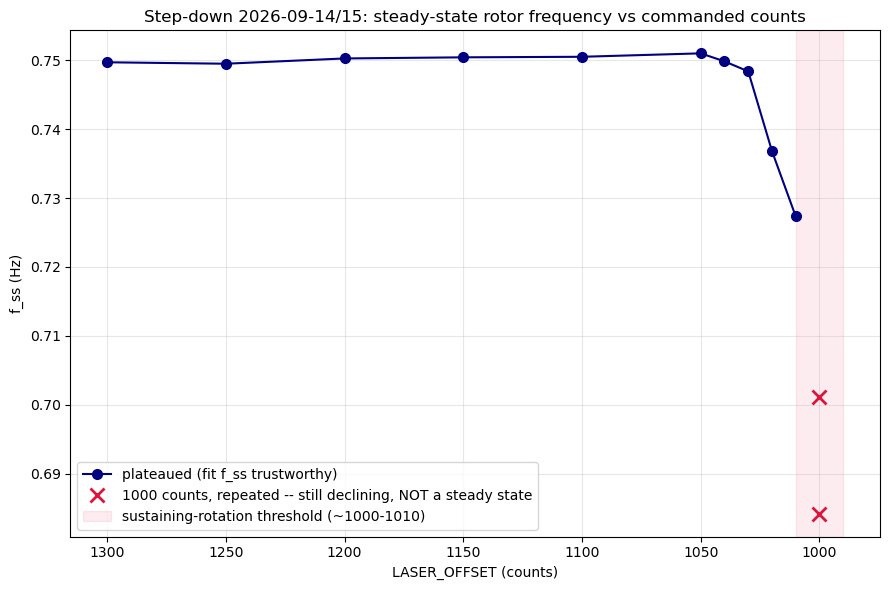

In [8]:
plateaued = [r for r in results if r['plateaued']]
not_plateaued = [r for r in results if not r['plateaued']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot([r['offset'] for r in plateaued], [r['f_ss'] for r in plateaued],
        'o-', color='navy', ms=7, label='plateaued (fit f_ss trustworthy)')
ax.plot([r['offset'] for r in not_plateaued], [r['f_ss'] for r in not_plateaued],
        'x', color='crimson', ms=10, mew=2,
        label='1000 counts, repeated -- still declining, NOT a steady state')
ax.axvspan(990, 1010, color='crimson', alpha=0.08,
           label='sustaining-rotation threshold (~1000-1010)')
ax.set_xlabel('LASER_OFFSET (counts)')
ax.set_ylabel('f_ss (Hz)')
ax.set_title('Step-down 2026-09-14/15: steady-state rotor frequency vs commanded counts')
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Conclusions

1. **Time period: front-end GPS 1473468171 -> ~1473530658, 2026-09-14 21:52 UTC ->
   2026-09-15 ~15:11 UTC (~17.3 h of controlled steps; 17.50 h pulled h5 window).**
2. **Sustaining-rotation threshold is ~1000-1010 counts** -- f_ss is essentially flat
   (0.7495-0.7510 Hz) from 1300 down through 1030, rolls over at 1020-1010, and at 1000
   the rotor never reaches a steady state at all (confirmed twice, i=10 and i=11).
3. **PD confirmed suspect** -- non-monotonic at the top of the range (rises 1300->1250
   before declining) and not a trustworthy power proxy here. Counts are the power axis
   for this dataset; a real counts->power calibration needs a fresh Ophir measurement
   with the PD path realigned.
4. Not done here (left for a follow-up pass): propagating a proper covariance / error
   bar on each f_ss from `curve_fit`, and using the CSV's own `check` lines (already
   time-stamped settled-check history) as a cross-check on the dense-tracker fit
   instead of refitting from raw LES alone.